In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import geopandas
import dask_geopandas
import json
from glob import glob
import time

sys.path.insert(1, os.path.abspath("../.."))
from qtree_index import nestedgrid, mortoncurve
from vectorstore import vectorstore

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a dataset

In [2]:
%%time
dataset = 'overture_building'
collection_id = 'vector-overture-building'

# Stac collection title
collection_title = 'Overture Building'

# Stac collection description
description = '''Overture building layers (type: building, building_part).'''

# Parquet file custom metadata
custom_meta_content = {'About': description}

dt_col = 'release_time'
geom_col = 'geometry'  # Needs to be called 'geometry'
id_col = 'id'
dimension_values = {}

# temporal_keys = [] #['year']
# temporal_partitions = [] #['year']

max_level = 26
target_level = 14
max_depth = 14
max_inflation = 100 #None
target_rows = 1e6

grid = nestedgrid.World(4326)
# Create or initialize an existing GeoDN vectorstore
vs = vectorstore.Vectorstore(
    dataset=dataset,
    collection_id=collection_id,
    dimension_values=dimension_values,
    grid=grid,
    dt_col=dt_col,
    geom_col=geom_col,
    id_col=id_col,
    max_level=max_level,
    target_level=target_level,
    max_depth=max_depth,
    max_inflation=max_inflation,
    target_rows=target_rows,
    custom_meta_content=custom_meta_content,
    verbose=True,
)

vs.write_metadata()
vs.read_metadata()

geoparquet_path = '/data/raster/overture/building_processed/'
files = glob(os.path.join(geoparquet_path, '**/*.parquet'))

cols = [
    'id', 
    'release_time',
    'name',
    'sources',
    'type', 
    'subtype',
    'class',
    'level',
    'has_parts',
    'building_id',
    'height',
    'is_underground',
    'num_floors',
    'num_floors_underground',
    'min_height',
    'min_floor',
    'facade_color',
    'facade_material',
    'roof_material',
    'roof_shape',
    'roof_direction',
    'roof_orientation',
    'roof_color',
    'roof_height', 
    'geometry', 
]

def load_clean_partial(file, cols):
    """Harmonize partial files before uploading."""
    gdf_part = geopandas.read_parquet(file)

    # # set UTC timestamp
    # # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
    # gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

    # # Fill in missing columns
    # missing_cols = list(set(cols) - set(gdf_part.columns))
    # for col in missing_cols:
    #     gdf_part[col] = None

    gdf_part['geometry'] = gdf_part['geometry'].make_valid()

    # Order the columns uniformly
    return gdf_part[cols]

len(files)

CPU times: total: 0 ns
Wall time: 17 ms


0

In [3]:
vars(vs)

{'grid': World(4326),
 'morton': <qtree_index.mortoncurve.Morton at 0x2b4ff580f90>,
 'valid_range': <POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))>,
 'dataset': 'overture_building',
 'collection_id': 'vector-overture-building',
 'temporal_levels': [],
 'dimension_values': {},
 'vectorstore_directory': 'data/vectorstore/',
 'dataset_directory': 'data/vectorstore/overture_building',
 'grid_directory': 'data/vectorstore/overture_building/grid=World(4326)',
 'geoparquet_directory': 'data/vectorstore/overture_building/grid=World(4326)/geoparquet',
 'index_directory': 'data/vectorstore/overture_building/grid=World(4326)/index',
 'dt_col': 'release_time',
 'key_col': '_root',
 'idx_col': '_idx',
 'geom_col': 'geometry',
 'id_col': 'id',
 'idx_box_col': 'idx_bounds',
 'geom_area_col': '_geom_area',
 'geom_length_col': '_geom_length',
 'primary_keys': ['release_time', 'id'],
 'max_level': 26,
 'target_level': 14,
 'max_depth': 14,
 'max_inflation': 100,
 'target_rows': 1000000.0,
 'ro

# Chunked successive ingestion

In [4]:
# %%time
# n_chunks = 1
# for i, chunk in enumerate(numpy.array_split(gdf_complete, n_chunks)):
#     print('Chunk', i)
#     vs.partial_upload(
#         chunk,
#         defrag=False,
#         index=False,
#         geometry_area=False,
#         geometry_length=False,
#     )

In [5]:
%%time
for file in files:
    print(file)
    chunk = load_clean_partial(file, cols)
    vs.partial_upload(
        chunk,
        defrag=False,
        index=False,
        geometry_area=False,
        geometry_length=False,
    )

/data/raster/overture/building_processed\type=building\part-00000-2ad9544f-1d68-4a5a-805c-7a5d020d084d-c000.zstd.parquet
df_root 11447790
Time for indexing the root of each unique geometry in seconds 116.7
distributed over 15 partitions
Time for creating partitions in seconds 56.688
Time for writing GeoDataFrame to GeoParquet partitions 199.941
/data/raster/overture/building_processed\type=building\part-00001-2ad9544f-1d68-4a5a-805c-7a5d020d084d-c000.zstd.parquet
df_root 11252712
Time for indexing the root of each unique geometry in seconds 135.414
distributed over 17 partitions
Time for creating partitions in seconds 48.392
Time for writing GeoDataFrame to GeoParquet partitions 208.783
/data/raster/overture/building_processed\type=building\part-00002-2ad9544f-1d68-4a5a-805c-7a5d020d084d-c000.zstd.parquet
df_root 11732095
Time for indexing the root of each unique geometry in seconds 137.596
distributed over 16 partitions
Time for creating partitions in seconds 57.848
Time for writing G

In [6]:
%%time
vs.unify_schemas()

Time for unify_schemas 3246.041
CPU times: total: 55min 52s
Wall time: 54min 6s


In [7]:
%%time
vs.defrag()

Time for defragging 19172.483
CPU times: total: 5h 5min 16s
Wall time: 5h 19min 32s


In [8]:
%%time
vs.repartition({})

level 0
source partition          target partition          records stay    records move   
0q                        0q13122013033             2998410         400            
0q                        0q10212313201             2998409         1              
0q                        0q02130130013             2998402         7              
0q                        0q10201323221             2998307         95             
0q                        0q10212213130             2998300         7              
0q                        0q02113212201             2998267         33             
0q                        0q10223210332             2998259         8              
0q                        0q10230233302             2998255         4              
0q                        0q10320021310             2998229         26             
0q                        0q11223033131             2998224         5              
0q                        0q11223033133             2998205         

In [9]:
%%time
vs.defrag()

Time for defragging 21473.461
CPU times: total: 5h 22min 1s
Wall time: 5h 57min 53s


In [10]:
# %%time
# vs.reindex({})

# Visualize spatial partitions

In [11]:
%%time
ddf = dask_geopandas.read_parquet(vs.geoparquet_directory, split_row_groups=False)
ddf

CPU times: total: 1.41 s
Wall time: 1min 11s


,id,release_time,name,sources,type,subtype,class,level,has_parts,building_id,height,is_underground,num_floors,num_floors_underground,min_height,min_floor,facade_color,facade_material,roof_material,roof_shape,roof_direction,roof_orientation,roof_color,roof_height,geometry,_root,grid,spatial_partition
npartitions=3106,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,object,"datetime64[us, UTC]",object,object,object,object,object,float64,bool,object,float64,bool,float64,float64,float64,float64,object,object,object,object,float64,object,object,float64,geometry,object,category[known],category[known]
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


<Axes: >

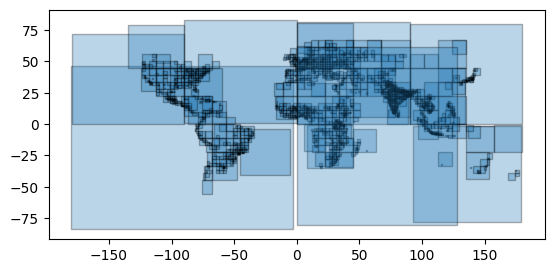

In [12]:
ddf.spatial_partitions.plot(edgecolor='k', alpha=0.3)

# Upload to COS and register in STAC

In [4]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('endpoint_url', '')
# S3 bucket
bucket = os.getenv('bucket', '')

# STAC url
stac_url = os.getenv('stac_url', 'https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com')
# STAC certificate
certificate = os.getenv('certificate', '/opt/app-root/src/ca.cert.txt')

#vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)
bucket

'claimed-test'

In [5]:
# vs.access_key_id = access_key_id
# vs.secret_access_key = secret_access_key
# vs.endpoint_url = endpoint_url
# vs.bucket = bucket
# vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

# storage_urls = vs.remote_fs.glob(os.path.join(vs.remote_geoparquet_directory, '**.parquet').replace('\\', '/'))
# storage_urls

In [6]:
# # GeoDN username
# geodn_username = os.getenv('geodn_username', '')
# # GeoDN password
# geodn_password = os.getenv('geodn_password', '')
# # GeoDN url
# GEODN_URL = os.getenv('GEODN_URL', "https://openeo-geodn-nasageospatial-dev.cash.sl.cloud9.ibm.com/openeo/1.1.0/")

In [7]:
stac_json_folder = os.path.join(vs.grid_directory, 'stac').replace('\\','/')

bbox = vs.grid.valid_bounds_wgs84
# df = pandas.read_parquet(vs.geoparquet_directory, columns=[vs.dt_col])
# dt_start = df[vs.dt_col].min()
# dt_end = df[vs.dt_col].max()
# Debug: Hack to get the specific overture timestamp in quickly
# dt_start = datetime(2024, 8, 20, tzinfo=pytz.utc)
# dt_end = datetime(2024, 8, 20, tzinfo=pytz.utc)

vs.to_stac_collection(
    stac_url,
    vs.collection_id,
    collection_title,
    stac_json_folder,
    certificate,
    bbox,
    dt_start,
    dt_end,
    description,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
)

In [31]:
%%time
# Upload to COS
upload_type = "replace_all" #"replace_all" "replace_partition" "add" "stac_items_only"
vs.to_cos(
    upload_type=upload_type,
    stac_url=stac_url,
    collection_id=vs.collection_id,
    collection_title=collection_title,
    stac_json_folder=stac_json_folder,
    certificate=certificate,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
    temporal_partitions=None,
    spatial_partitions=None,
)

uploading to remote_path claimed-test/vectorstore/overture_building/grid=World(4326)/geoparquet/spatial_partition=0q130200303/d172e7be7ed0415bb555bbcd8c285b5c.parquet
schema.names ['id', 'release_time', 'name', 'sources', 'type', 'subtype', 'class', 'level', 'has_parts', 'building_id', 'height', 'is_underground', 'num_floors', 'num_floors_underground', 'min_height', 'min_floor', 'facade_color', 'facade_material', 'roof_material', 'roof_shape', 'roof_direction', 'roof_orientation', 'roof_color', 'roof_height', 'geometry', '_root']
schema.types [DataType(string), TimestampType(timestamp[us, tz=UTC]), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(double), DataType(bool), DataType(string), DataType(double), DataType(bool), DataType(double), DataType(double), DataType(double), DataType(double), DataType(string), DataType(string), DataType(string), DataType(string), DataType(double), DataType(string), DataType(string), DataType(double), Da